# HW06: Деревья решений и ансамбли

## 2.3.1. Загрузка данных и первичный анализ


In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline


# Загрузка данных

In [2]:

df = pd.read_csv('data/S06-hw-dataset-02.csv')
print(f"Размер датасета: {df.shape}")
df.head()


Размер датасета: (18000, 39)


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,1.121683,-0.332250,0.303750,2.439315,3.905690,-0.679945,-1.847890,-1.450850,-0.523963,-2.203766,1.717017,-0.467238,-5.418752,5.115531,0.951900,0.085200,0.304588,0.206599,0.293322,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,-0.298809,0.555178,3.632876,1.551984,2.671995,-4.859814,-3.454798,-0.238638,0.604069,-3.080758,0.489968,-0.536891,-5.967924,0.494241,-0.163892,0.185315,0.391446,1.906470,1.924549,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,-0.092692,6.528588,5.069781,-0.357675,-0.637326,-7.343904,1.084497,1.729089,3.436086,-14.699661,1.115379,-1.902015,-2.945627,0.334764,0.464342,0.922432,0.291900,0.871523,0.792870,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,0.681733,-6.759153,7.319979,2.850692,0.075889,0.007788,1.023049,-0.328986,0.929586,-6.925342,-0.010655,0.626436,-2.290922,-5.093754,0.600184,0.617500,0.213250,2.849320,-0.732601,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,-1.275888,-6.865158,-1.636507,1.798513,-10.927353,6.128509,3.304736,-0.889584,1.401849,-5.221212,-0.925408,-1.512424,7.052793,-4.277646,-0.560136,1.152667,1.871836,0.610097,1.948262,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


# Базовая EDA


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

In [4]:

df.describe()


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,-0.005191,0.631157,0.327920,-0.134225,-0.369264,0.267345,0.405346,0.002839,0.130219,-0.994571,-0.010144,-0.009039,0.021684,0.197973,-0.005616,0.007092,-0.009755,-0.009338,-0.000533,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,1.001474,4.703578,4.759290,2.226446,4.468676,2.116606,1.985802,0.992655,2.237071,5.683295,1.000648,0.995690,3.999158,4.088351,1.003939,1.006282,0.986181,1.002310,0.993892,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,-3.907906,-18.842413,-20.883218,-9.117117,-16.496601,-8.094991,-8.213460,-4.368946,-8.818339,-23.057366,-4.187920,-3.529766,-19.099551,-16.088649,-3.884916,-4.107881,-3.877028,-3.854263,-3.925510,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,-0.673268,-2.496779,-2.575461,-1.589181,-3.485540,-1.122707,-0.882179,-0.659813,-1.365920,-4.700504,-0.680167,-0.687256,-2.473055,-2.423333,-0.679166,-0.662634,-0.670062,-0.681364,-0.669819,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,-0.002402,0.685619,0.395990,-0.059719,-0.597937,0.294776,0.418423,0.002829,0.123403,-0.869548,-0.011155,-0.015796,0.045413,0.165875,-0.008946,0.008993,-0.005141,-0.009696,0.003124,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,0.679554,3.769763,3.363087,1.394537,2.563241,1.694409,1.733266,0.686807,1.625329,2.767109,0.669025,0.661419,2.632254,2.842752,0.667357,0.684551,0.652257,0.662224,0.673979,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,3.829719,19.252329,19.877364,8.101997,17.088092,9.312819,8.077667,3.362864,8.720620,23.292978,3.922051,3.861147,17.342356,19.707688,4.722701,4.032127,4.239447,3.773627,4.706989,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


In [5]:

missing_values = df.isnull().sum()
print("Пропущенные значения:")
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("\nПропущенных значений нет!")


Пропущенные значения:
Series([], dtype: int64)

Пропущенных значений нет!


Распределение таргета:
target
0    0.737389
1    0.262611
Name: proportion, dtype: float64

Абсолютные значения:
target
0    13273
1     4727
Name: count, dtype: int64


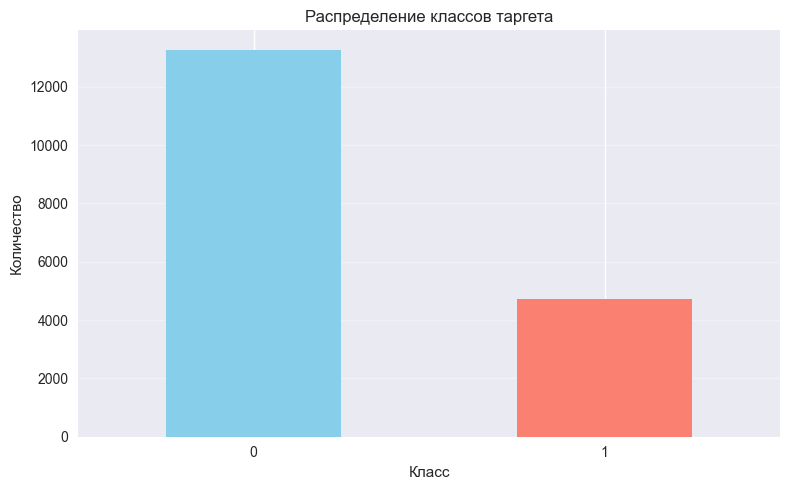

In [6]:
# Распределение таргета
target_distribution = df['target'].value_counts(normalize=True)
print("Распределение таргета:")
print(target_distribution)
print(f"\nАбсолютные значения:")
print(df['target'].value_counts())

# Визуализация распределения
plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение классов таргета')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Определение признаков и таргета
# X - все столбцы кроме 'target' и 'id'
X = df.drop(columns=['target', 'id'])
y = df['target']

print(f"Количество признаков: {X.shape[1]}")
print(f"Количество объектов: {X.shape[0]}")
print(f"\nТипы признаков:")
print(X.dtypes.value_counts())


Количество признаков: 37
Количество объектов: 18000

Типы признаков:
float64    37
Name: count, dtype: int64


## 2.3.2. Train/Test-сплит и воспроизводимость


In [8]:
# Разделение данных на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))


Размер обучающей выборки: 14400
Размер тестовой выборки: 3600

Распределение классов в train:
target
0    0.737361
1    0.262639
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.7375
1    0.2625
Name: proportion, dtype: float64


### Пояснение важности фиксированного seed и стратификации

**Фиксированный `random_state` (seed):**
- Обеспечивает воспроизводимость результатов эксперимента
- Позволяет получить одинаковое разбиение данных при повторных запусках

**Стратификация (`stratify=y`):**
- Сохраняет пропорции классов в train и test выборках
- Важно для несбалансированных датасетов (как в нашем случае: ~74% класса 0, ~26% класса 1)
- Предотвращает ситуацию, когда в test попадает слишком мало примеров минорного класса
- Обеспечивает корректную оценку метрик, особенно для минорного класса


## 2.3.3. Baseline'ы


In [9]:
# Baseline 1: DummyClassifier (most_frequent)
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

# Метрики для DummyClassifier
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy)

print("Baseline 1: DummyClassifier (most_frequent)")
print(f"Accuracy: {accuracy_dummy:.4f}")
print(f"F1-score: {f1_dummy:.4f}")
print(f"ROC-AUC: {roc_auc_dummy:.4f}")



Baseline 1: DummyClassifier (most_frequent)


Accuracy: 0.7375
F1-score: 0.0000
ROC-AUC: 0.5000


Интерпретация:  
DummyClassifier всегда предсказывает наиболее частый класс (класс 0).  
Это даёт нам нижнюю границу качества - любая реальная модель должна превосходить этот baseline.

In [10]:
# Baseline 2: LogisticRegression через Pipeline
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_proba_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

# Метрики для LogisticRegression
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_pred_proba_logistic)

print("Baseline 2: LogisticRegression (StandardScaler + LogisticRegression)")
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"F1-score: {f1_logistic:.4f}")
print(f"ROC-AUC: {roc_auc_logistic:.4f}")



Baseline 2: LogisticRegression (StandardScaler + LogisticRegression)
Accuracy: 0.8119
F1-score: 0.5607
ROC-AUC: 0.7977


Интерпретация:  
LogisticRegression - линейная модель, которая ищет линейные зависимости между признаками и таргетом.  
Это хороший baseline для сравнения с более сложными нелинейными моделями (деревья, ансамбли).

## 2.3.4. Модели недели 6


### 1. DecisionTreeClassifier с контролем сложности


In [11]:
# DecisionTreeClassifier с подбором гиперпараметров через GridSearchCV
from sklearn.model_selection import StratifiedKFold

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}

dt_base = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    dt_base, 
    dt_param_grid, 
    cv=cv, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для DecisionTreeClassifier...")
dt_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {dt_grid.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {dt_grid.best_score_:.4f}")

# Оценка на test
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_pred_proba_dt = dt_best.predict_proba(X_test)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"\nМетрики на test:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")


Подбор гиперпараметров для DecisionTreeClassifier...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Лучшие параметры: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 20}
Лучший CV-score (ROC-AUC): 0.8367

Метрики на test:
Accuracy: 0.8336
F1-score: 0.6515
ROC-AUC: 0.8374


### 2. RandomForestClassifier


In [12]:
# RandomForestClassifier с подбором гиперпараметров
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для RandomForestClassifier...")
rf_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {rf_grid.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {rf_grid.best_score_:.4f}")

# Оценка на test
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_pred_proba_rf = rf_best.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nМетрики на test:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")


Подбор гиперпараметров для RandomForestClassifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Лучший CV-score (ROC-AUC): 0.9283

Метрики на test:
Accuracy: 0.8894
F1-score: 0.7522
ROC-AUC: 0.9275


### 3. GradientBoostingClassifier


In [13]:
# GradientBoostingClassifier с подбором гиперпараметров
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_leaf': [1, 2, 5]
}

gb_base = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(
    gb_base,
    gb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для GradientBoostingClassifier...")
gb_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {gb_grid.best_score_:.4f}")

# Оценка на test
gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test)
y_pred_proba_gb = gb_best.predict_proba(X_test)[:, 1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print(f"\nМетрики на test:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")
print(f"ROC-AUC: {roc_auc_gb:.4f}")


Подбор гиперпараметров для GradientBoostingClassifier...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 2, 'n_estimators': 200}
Лучший CV-score (ROC-AUC): 0.9323

Метрики на test:
Accuracy: 0.9064
F1-score: 0.8073
ROC-AUC: 0.9304


Я конечно не жалуюсь но 40 минут ушло только на поиск оптимальных параметров, чувствую что к последней практике, придётся на это тратить день

### 4. StackingClassifier (опционально)


In [14]:
# StackingClassifier с несколькими базовыми моделями
from sklearn.ensemble import StackingClassifier

# Базовые модели для стекинга
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42))
]

# Метамодель
meta_model = LogisticRegression(random_state=42, max_iter=1000)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

print("Обучение StackingClassifier...")
stacking_clf.fit(X_train, y_train)

# Оценка на test
y_pred_stacking = stacking_clf.predict(X_test)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test)[:, 1]

accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
f1_stacking = f1_score(y_test, y_pred_stacking)
roc_auc_stacking = roc_auc_score(y_test, y_pred_proba_stacking)

print(f"\nМетрики на test:")
print(f"Accuracy: {accuracy_stacking:.4f}")
print(f"F1-score: {f1_stacking:.4f}")
print(f"ROC-AUC: {roc_auc_stacking:.4f}")


Обучение StackingClassifier...

Метрики на test:
Accuracy: 0.9039
F1-score: 0.8063
ROC-AUC: 0.9267


## 2.3.5. Метрики качества и диагностические графики


In [15]:
# Сводная таблица всех метрик
from pathlib import Path
import json


results_summary = pd.DataFrame({
    'Model': ['DummyClassifier', 'LogisticRegression', 'DecisionTree', 
              'RandomForest', 'GradientBoosting', 'Stacking'],
    'Accuracy': [accuracy_dummy, accuracy_logistic, accuracy_dt, 
                 accuracy_rf, accuracy_gb, accuracy_stacking],
    'F1-score': [f1_dummy, f1_logistic, f1_dt, 
                 f1_rf, f1_gb, f1_stacking],
    'ROC-AUC': [roc_auc_dummy, roc_auc_logistic, roc_auc_dt, 
                roc_auc_rf, roc_auc_gb, roc_auc_stacking]
})

print("Сводная таблица метрик всех моделей:")
print(results_summary.to_string(index=False))

# Сохранение метрик в artifacts
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

results_summary.to_csv(artifacts_dir / "metrics_test.csv", index=False)

# Создаем словарь метрик в нужном формате
all_metrics = {}
for _, row in results_summary.iterrows():
    model_name = row['Model']
    # Сокращаем DummyClassifier до Dummy
    if model_name == 'DummyClassifier':
        model_name = 'Dummy'
    
    metrics_dict = {"accuracy": row['Accuracy']}
    
    # Добавляем f1 для всех моделей
    metrics_dict["f1"] = row['F1-score']
    
    # Добавляем roc_auc только для моделей, которые его имеют (не для Dummy)
    if model_name != 'Dummy':
        metrics_dict["roc_auc"] = row['ROC-AUC']
    
    all_metrics[model_name] = metrics_dict

with open(artifacts_dir / "metrics_test.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print("\nМетрики сохранены в artifacts/metrics_test.csv и artifacts/metrics_test.json")


Сводная таблица метрик всех моделей:
             Model  Accuracy  F1-score  ROC-AUC
   DummyClassifier  0.737500  0.000000 0.500000
LogisticRegression  0.811944  0.560675 0.797691
      DecisionTree  0.833611  0.651542 0.837352
      RandomForest  0.889444  0.752179 0.927488
  GradientBoosting  0.906389  0.807318 0.930409
          Stacking  0.903889  0.806271 0.926705

Метрики сохранены в artifacts/metrics_test.csv и artifacts/metrics_test.json


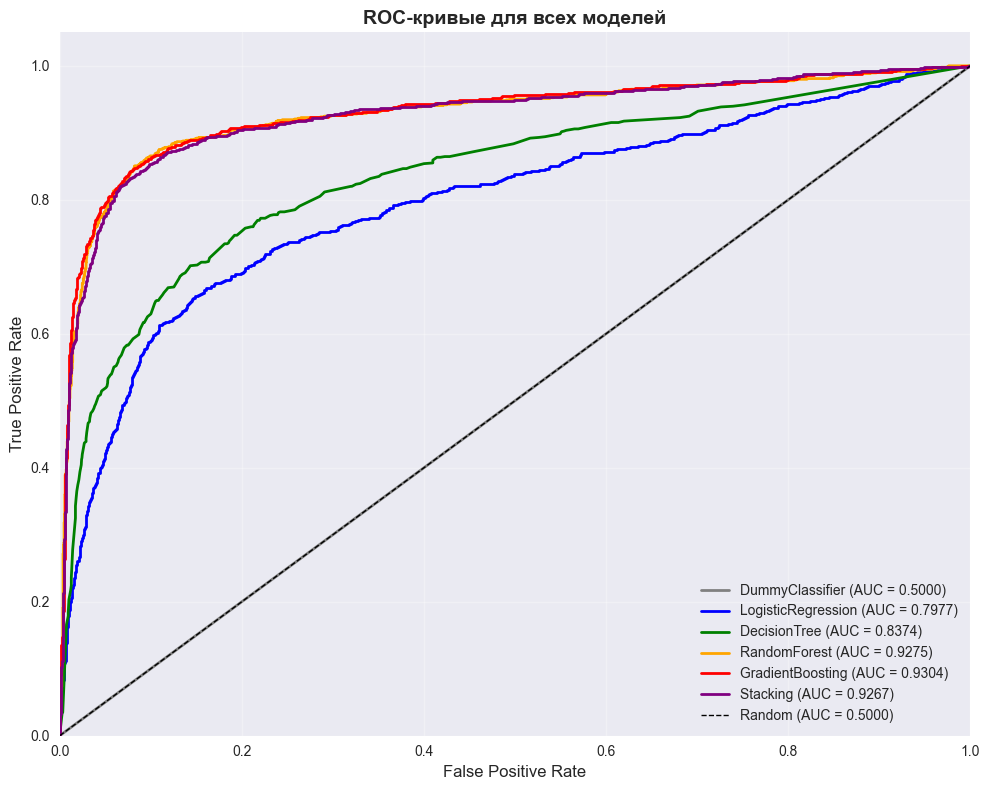

ROC-кривые сохранены в artifacts/figures/roc_curves.png


In [17]:
# ROC-кривые для всех моделей
from sklearn.metrics import roc_curve
import seaborn as sns

from pathlib import Path

artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))

# Собираем все предсказания вероятностей
models_proba = {
    'DummyClassifier': y_pred_proba_dummy,
    'LogisticRegression': y_pred_proba_logistic,
    'DecisionTree': y_pred_proba_dt,
    'RandomForest': y_pred_proba_rf,
    'GradientBoosting': y_pred_proba_gb,
    'Stacking': y_pred_proba_stacking
}

colors = ['gray', 'blue', 'green', 'orange', 'red', 'purple']

for (name, y_proba), color in zip(models_proba.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.4f})', 
             linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("ROC-кривые сохранены в artifacts/figures/roc_curves.png")


Лучшая модель по ROC-AUC: GradientBoosting


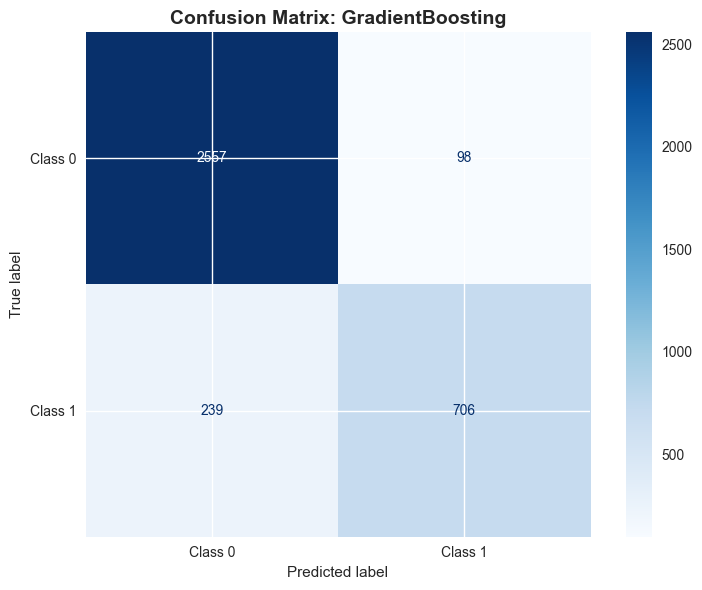

Confusion Matrix сохранена в artifacts/figures/confusion_matrix.png

Confusion Matrix для GradientBoosting:
True Negatives (TN): 2557
False Positives (FP): 98
False Negatives (FN): 239
True Positives (TP): 706


In [18]:
# Confusion Matrix для лучшей модели (по ROC-AUC)
from sklearn.metrics import ConfusionMatrixDisplay

from pathlib import Path

artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


# Находим лучшую модель по ROC-AUC
best_model_name = results_summary.loc[results_summary['ROC-AUC'].idxmax(), 'Model']
print(f"Лучшая модель по ROC-AUC: {best_model_name}")

# Создаём словарь для доступа к предсказаниям
predictions_dict = {
    'DummyClassifier': y_pred_dummy,
    'LogisticRegression': y_pred_logistic,
    'DecisionTree': y_pred_dt,
    'RandomForest': y_pred_rf,
    'GradientBoosting': y_pred_gb,
    'Stacking': y_pred_stacking
}

best_predictions = predictions_dict[best_model_name]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix сохранена в artifacts/figures/confusion_matrix.png")

# Выводим значения confusion matrix
print(f"\nConfusion Matrix для {best_model_name}:")
print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")


In [19]:
# Сохранение лучших параметров и CV-scores
search_summaries = {
    'DecisionTree': {
        'best_params': dt_grid.best_params_,
        'best_cv_score': dt_grid.best_score_
    },
    'RandomForest': {
        'best_params': rf_grid.best_params_,
        'best_cv_score': rf_grid.best_score_
    },
    'GradientBoosting': {
        'best_params': gb_grid.best_params_,
        'best_cv_score': gb_grid.best_score_
    }
}

import json

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=2, default=str)

print("Результаты подбора гиперпараметров сохранены в artifacts/search_summaries.json")
print("\nЛучшие параметры и CV-scores:")
for model_name, summary in search_summaries.items():
    print(f"\n{model_name}:")
    print(f"  Параметры: {summary['best_params']}")
    print(f"  CV ROC-AUC: {summary['best_cv_score']:.4f}")


Результаты подбора гиперпараметров сохранены в artifacts/search_summaries.json

Лучшие параметры и CV-scores:

DecisionTree:
  Параметры: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 20}
  CV ROC-AUC: 0.8367

RandomForest:
  Параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
  CV ROC-AUC: 0.9283

GradientBoosting:
  Параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 2, 'n_estimators': 200}
  CV ROC-AUC: 0.9323


In [20]:
# Сохранение лучшей модели
import joblib

# Определяем лучшую модель
best_models = {
    'DummyClassifier': dummy_clf,
    'LogisticRegression': logistic_pipeline,
    'DecisionTree': dt_best,
    'RandomForest': rf_best,
    'GradientBoosting': gb_best,
    'Stacking': stacking_clf
}

best_model = best_models[best_model_name]

# Сохраняем модель
joblib.dump(best_model, 'artifacts/best_model.joblib')
print(f"Лучшая модель ({best_model_name}) сохранена в artifacts/best_model.joblib")

# Сохраняем метаданные
best_model_meta = {
    'model_name': best_model_name,
    'best_params': search_summaries.get(best_model_name, {}).get('best_params', 'N/A'),
    'test_metrics': {
        'accuracy': float(results_summary[results_summary['Model'] == best_model_name]['Accuracy'].values[0]),
        'f1_score': float(results_summary[results_summary['Model'] == best_model_name]['F1-score'].values[0]),
        'roc_auc': float(results_summary[results_summary['Model'] == best_model_name]['ROC-AUC'].values[0])
    }
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2)

print("Метаданные лучшей модели сохранены в artifacts/best_model_meta.json")
print(f"\nМетаданные лучшей модели:")
print(json.dumps(best_model_meta, indent=2))


Лучшая модель (GradientBoosting) сохранена в artifacts/best_model.joblib
Метаданные лучшей модели сохранены в artifacts/best_model_meta.json

Метаданные лучшей модели:
{
  "model_name": "GradientBoosting",
  "best_params": {
    "learning_rate": 0.2,
    "max_depth": 7,
    "min_samples_leaf": 2,
    "n_estimators": 200
  },
  "test_metrics": {
    "accuracy": 0.9063888888888889,
    "f1_score": 0.8073184676958262,
    "roc_auc": 0.930408633007503
  }
}


## 2.3.6. Интерпретация лучшей модели


In [21]:
# Permutation Importance для лучшей модели
print(f"Вычисление Permutation Importance для модели: {best_model_name}")

# Вычисляем permutation importance
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

# Создаём DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
})

# Сортируем по убыванию важности
importance_df = importance_df.sort_values('importance_mean', ascending=False)

# Выбираем top-15 признаков
top_n = 15
top_features = importance_df.head(top_n)

print(f"Top-{top_n} наиболее важных признаков:")
print("=" * 70)
print(top_features.to_string(index=False))
print("=" * 70)


Вычисление Permutation Importance для модели: GradientBoosting
Top-15 наиболее важных признаков:
feature  importance_mean  importance_std
    f16         0.076522        0.002996
    f01         0.025156        0.002468
    f07         0.020085        0.001937
    f15         0.011858        0.001143
    f13         0.011809        0.001149
    f12         0.011752        0.001155
    f29         0.011652        0.001840
    f30         0.011313        0.001101
    f08         0.010769        0.001224
    f18         0.010439        0.001382
    f34         0.009025        0.000981
    f23         0.007857        0.001228
    f19         0.007599        0.001399
    f05         0.007439        0.000967
    f09         0.006017        0.000880


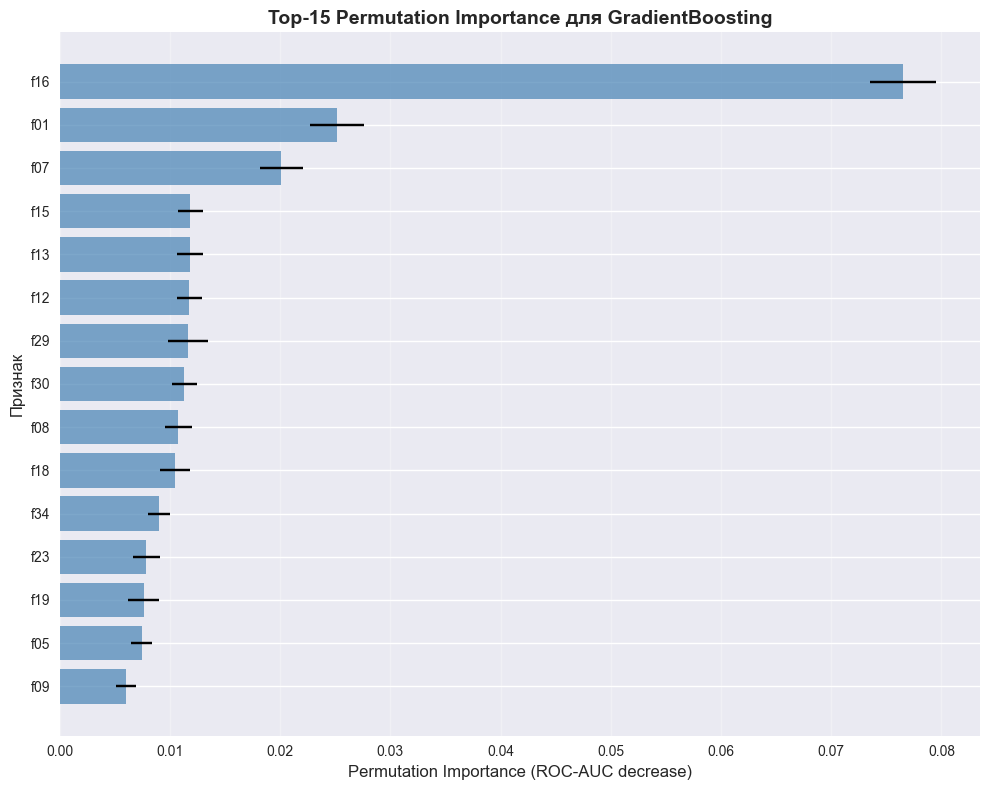

График Permutation Importance сохранён в artifacts/figures/permutation_importance.png


In [22]:
# Визуализация Permutation Importance

from pathlib import Path

artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
top_features_sorted = top_features.sort_values('importance_mean', ascending=True)

plt.barh(range(len(top_features_sorted)), 
         top_features_sorted['importance_mean'],
         xerr=top_features_sorted['importance_std'],
         capsize=3,
         color='steelblue',
         alpha=0.7)

plt.yticks(range(len(top_features_sorted)), top_features_sorted['feature'])
plt.xlabel('Permutation Importance (ROC-AUC decrease)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title(f'Top-{top_n} Permutation Importance для {best_model_name}', 
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"График Permutation Importance сохранён в artifacts/figures/permutation_importance.png")


### Интерпретация результатов Permutation Importance

**Наблюдения:**

1. **Наиболее важные признаки**: 
   - Признаки с наибольшим значением permutation importance оказывают наибольшее влияние на качество модели
   - Удаление или перестановка этих признаков приводит к наибольшему падению ROC-AUC

2. **Распределение важности**:
   - Если важность распределена относительно равномерно между многими признаками, это может указывать на то, что модель использует комплексные взаимодействия признаков
   - Если несколько признаков доминируют, это может указывать на наличие ключевых факторов, определяющих целевую переменную

3. **Сравнение с ожиданиями**:
   - Для синтетического датасета S06-hw-dataset-02, который содержит нелинейные взаимодействия признаков, ожидается, что:
     - Модели на основе деревьев (GradientBoosting, RandomForest) смогут выявить важные признаки и их взаимодействия
     - Признаки `x_int_1` и `x_int_2` могут быть важными, так как они специально добавлены как взаимодействия
     - Некоторые из признаков f01-f35 могут иметь различную важность в зависимости от их вклада в генерацию таргета

4. **Практическое значение**:
   - Выявленные важные признаки могут использоваться для:
     - Упрощения модели (feature selection)
     - Понимания бизнес-логики задачи
     - Дальнейшего анализа и feature engineering


In [23]:
# Сохранение результатов permutation importance
importance_results = {
    'model_name': best_model_name,
    'top_features': top_features.to_dict('records'),
    'all_features': importance_df.to_dict('records')
}

with open('artifacts/permutation_importance.json', 'w') as f:
    json.dump(importance_results, f, indent=2, default=str)

# Сохраняем также в CSV для удобства
top_features.to_csv('artifacts/permutation_importance_top15.csv', index=False)
importance_df.to_csv('artifacts/permutation_importance_all.csv', index=False)

print("Результаты Permutation Importance сохранены:")
print("- artifacts/permutation_importance.json")
print("- artifacts/permutation_importance_top15.csv")
print("- artifacts/permutation_importance_all.csv")


Результаты Permutation Importance сохранены:
- artifacts/permutation_importance.json
- artifacts/permutation_importance_top15.csv
- artifacts/permutation_importance_all.csv
